In [3]:
# https://arxiv.org/pdf/1706.03762
# Attention Is All You Need: arXiv:1706.03762v7 [cs.CL] 2 Aug 2023

# Imports
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# A attention function
class Attention(nn.Module):
    def __init__(self, seq_len=200):
      super(Attention, self).__init__()
      self.queries = nn.Linear(seq_len, seq_len)
      self.keys = nn.Linear(seq_len, seq_len)
      self.values = nn.Linear(seq_len, seq_len)

    def forward(self, x, mask=True):
      q = self.queries(x).reshape(x.shape[0], x.shape[1], 1)
      k = self.keys(x).reshape(x.shape[0], x.shape[1], 1)
      v = self.values(x).reshape(x.shape[0], x.shape[1], 1)
      scores = torch.bmm(q, k.transpose(-2, -1))
      if mask:
        maskmat = torch.tril(torch.ones((x.shape[1], x.shape[1])))
        scores = scores.masked_fill(maskmat == 0, -1e9)
      attention_weights = F.softmax(scores, dim=-1)
      output = torch.bmm(attention_weights, v)
      return output.reshape(output.shape[0], output.shape[1])


  # A forecasting model
class ForecastingModel(nn.Module):
    def __init__(self, seq_len=200, ffdim=64):
      super(ForecastingModel, self).__init__()
      self.relu = nn.ReLU()
      self.attention = Attention(seq_len)
      self.linear1 = nn.Linear(seq_len, int(ffdim))
      self.linear2 = nn.Linear(int(ffdim), int(ffdim/2))
      self.linear3 = nn.Linear(int(ffdim/2), int(ffdim/4))
      self.outlayer = nn.Linear(int(ffdim/4), 1)

    def forward(self, x):
      x = self.attention(x)
      x = self.relu(self.linear1(x))
      x = self.relu(self.linear2(x))
      x = self.relu(self.linear3(x))
      return self.outlayer(x)


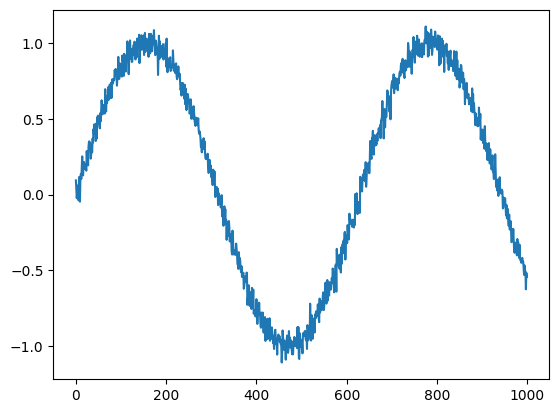

In [14]:
# TEST: sin + noise
DATA_SIZE = 1000
x = np.sin(np.linspace(0, 10, DATA_SIZE)) + np.random.normal(0, 0.05, DATA_SIZE)
plt.plot(range(x.shape[0]), x)
plt.show()

In [7]:
# A dataset
seq_len = 200
X = np.array([x[ii:ii+seq_len] for ii in range(0, x.shape[0] - seq_len)])
Y = np.array([x[ii+seq_len] for ii in range(0, x.shape[0] - seq_len)])

# Training loop
EPOCHS = 20
BATCH_SIZE = 8
LEARNING_RATE = 4e-5
model = ForecastingModel(seq_len)
model.train()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
dataset = TensorDataset(torch.Tensor(X), torch.Tensor(Y))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE)
for epoch in range(EPOCHS):
  for xx, yy in dataloader:
    optimizer.zero_grad()
    out = model(xx)
    loss = criterion(out, yy)
    loss.backward()
    optimizer.step()
  print(f"Epoch: {epoch+1}/{EPOCHS}, Loss: {loss}")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch: 1/20, Loss: 0.27793848514556885
Epoch: 2/20, Loss: 0.2570527493953705
Epoch: 3/20, Loss: 0.1534443497657776
Epoch: 4/20, Loss: 0.03080795705318451
Epoch: 5/20, Loss: 0.0028243018314242363
Epoch: 6/20, Loss: 0.003229619935154915
Epoch: 7/20, Loss: 0.0031273544300347567
Epoch: 8/20, Loss: 0.0029635680839419365
Epoch: 9/20, Loss: 0.0029309920500963926
Epoch: 10/20, Loss: 0.0028960497584193945
Epoch: 11/20, Loss: 0.0029106277506798506
Epoch: 12/20, Loss: 0.0029138801619410515
Epoch: 13/20, Loss: 0.0029204185120761395
Epoch: 14/20, Loss: 0.00292344787158072
Epoch: 15/20, Loss: 0.002925819717347622
Epoch: 16/20, Loss: 0.0029278818983584642
Epoch: 17/20, Loss: 0.002929405076429248
Epoch: 18/20, Loss: 0.002930270042270422
Epoch: 19/20, Loss: 0.0029311857651919127
Epoch: 20/20, Loss: 0.002932320348918438


In [8]:
# Predictive loop
FORECAST = 1000
model.eval()
for ff in range(FORECAST):
  xx = x[len(x)-seq_len:len(x)]
  yy = model(torch.Tensor(xx).reshape(1, xx.shape[0]))
  x = np.concatenate((x, yy.detach().numpy().reshape(1,)))


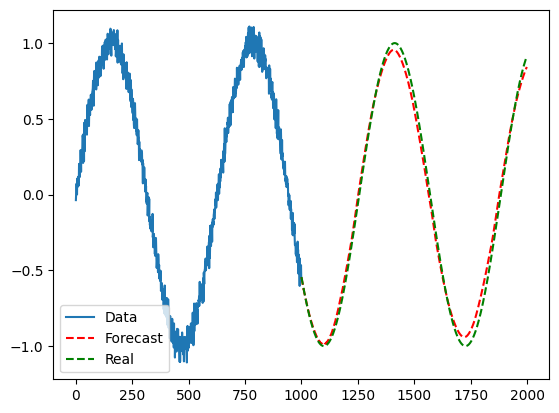

In [13]:
# Plots results
plt.plot(range(x[:DATA_SIZE].shape[0]), x[:DATA_SIZE], label="Data")
plt.plot(range(x[:DATA_SIZE].shape[0], x.shape[0]), x[DATA_SIZE:DATA_SIZE+FORECAST], 'r--', label="Forecast")
plt.plot(range(x[:DATA_SIZE].shape[0], x.shape[0]), np.sin(np.linspace(10, 20, DATA_SIZE)), 'g--', label="Real")
plt.legend()
plt.show()

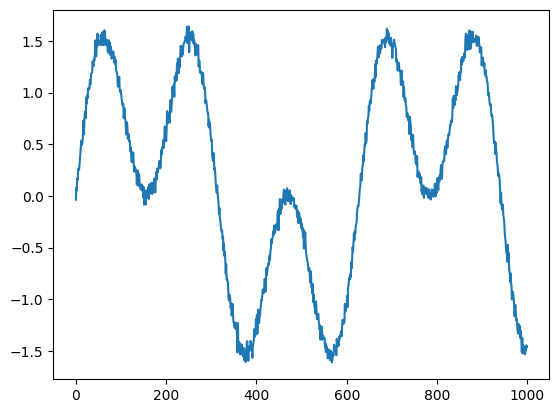

In [51]:
# TEST: sin(x) + sin(3x) + noise
DATA_SIZE = 1000
x = np.sin(3 * np.linspace(0, 10, DATA_SIZE)) + np.sin(np.linspace(0, 10, DATA_SIZE)) + np.random.normal(0, 0.05, DATA_SIZE)
plt.plot(range(x.shape[0]), x)
plt.show()

In [86]:
# A dataset
seq_len = 400
X = np.array([x[ii:ii+seq_len] for ii in range(0, x.shape[0] - seq_len)])
Y = np.array([x[ii+seq_len] for ii in range(0, x.shape[0] - seq_len)])

# Training loop
EPOCHS = 20
BATCH_SIZE = 16
LEARNING_RATE = 5e-5
model = ForecastingModel(seq_len)
model.train()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
dataset = TensorDataset(torch.Tensor(X), torch.Tensor(Y))
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE)
for epoch in range(EPOCHS):
  for xx, yy in dataloader:
    optimizer.zero_grad()
    out = model(xx)
    loss = criterion(out, yy)
    loss.backward()
    optimizer.step()
  print(f"Epoch: {epoch+1}/{EPOCHS}, Loss: {loss}")

Epoch: 1/20, Loss: 1.7210683822631836
Epoch: 2/20, Loss: 1.5496540069580078
Epoch: 3/20, Loss: 1.3660480976104736
Epoch: 4/20, Loss: 0.897650420665741
Epoch: 5/20, Loss: 0.26363515853881836
Epoch: 6/20, Loss: 0.027113165706396103
Epoch: 7/20, Loss: 0.0036397220101207495
Epoch: 8/20, Loss: 0.006626754999160767
Epoch: 9/20, Loss: 0.005236151162534952
Epoch: 10/20, Loss: 0.0055014025419950485
Epoch: 11/20, Loss: 0.0047546918503940105
Epoch: 12/20, Loss: 0.0042327591218054295
Epoch: 13/20, Loss: 0.0037900484167039394
Epoch: 14/20, Loss: 0.0034031569957733154
Epoch: 15/20, Loss: 0.0031989184208214283
Epoch: 16/20, Loss: 0.0026403169613331556
Epoch: 17/20, Loss: 0.002511895028874278
Epoch: 18/20, Loss: 0.0022673981729894876
Epoch: 19/20, Loss: 0.002322060987353325
Epoch: 20/20, Loss: 0.001962104346603155


In [87]:
# Predictive loop
FORECAST = 1000
model.eval()
xxx = x[:]
for ff in range(FORECAST):
  xx = xxx[len(xxx)-seq_len:len(xxx)]
  yy = model(torch.Tensor(xx).reshape(1, xx.shape[0]))
  xxx = np.concatenate((xxx, yy.detach().numpy().reshape(1,)))


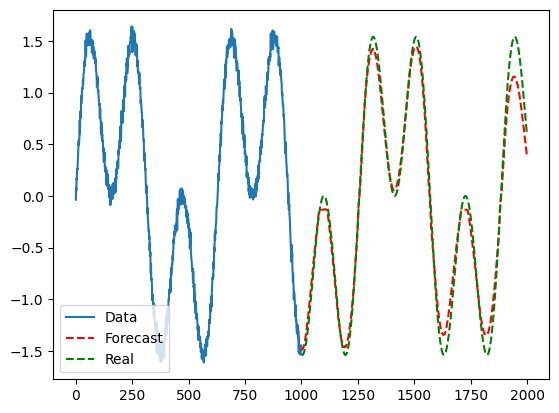

In [88]:
# Plots results
plt.plot(range(xxx[:DATA_SIZE].shape[0]), xxx[:DATA_SIZE], label="Data")
plt.plot(range(xxx[:DATA_SIZE].shape[0], xxx.shape[0]), xxx[DATA_SIZE:DATA_SIZE+FORECAST], 'r--', label="Forecast")
plt.plot(range(xxx[:DATA_SIZE].shape[0], xxx.shape[0]), np.sin(3 * np.linspace(10, 20, DATA_SIZE)) + np.sin(np.linspace(10, 20, DATA_SIZE)), 'g--', label="Real")
plt.legend()
plt.show()